In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import make_column_transformer

df=pd.read_csv('Project_description_and_data/claims_train.csv')

def transform(df):
    df = df.copy()
    df['VehAge_1']=df['VehAge'] +1                   
    df['VehAge_log']=np.log(df['VehAge_1'])
    df['DrivAge_log']=np.log(df['DrivAge'])
    df['Density_log']=np.log(df['Density'])
    df['VehGas'] = np.where(df['VehGas'] == 'Regular', 0, 1)
    df.drop(['VehAge', 'VehAge_1', 'DrivAge', 'Density'], axis=1, inplace=True)
    
    categorical_features = ['VehBrand', 'VehGas', 'Area', 'Region']
    numerical_features = [col for col in df.columns if col not in categorical_features]
    preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), categorical_features),
        ('num', StandardScaler(), numerical_features)],
         remainder='drop')
    preprocessor.set_output(transform="pandas")
    new_df = preprocessor.fit_transform(df)
    new_df.columns = [col.split("__")[-1] for col in new_df.columns]
    return new_df
    

d = transform(df)
d

,VehBrand,VehGas,Area,Region,IDpol,ClaimNb,Exposure,VehPower,BonusMalus,VehAge_log,DrivAge_log,Density_log
0,0.0,0.0,3.0,4.0,-0.304991,-0.222468,-0.271193,0.266627,2.253198,1.351263,-0.578146,0.522312
1,6.0,0.0,3.0,5.0,0.335094,-0.222468,-1.176636,0.266627,2.253198,1.288734,1.921500,0.219478
2,10.0,0.0,4.0,17.0,-0.873818,-0.222468,-0.545570,0.266627,1.038310,-0.450730,-0.578146,1.257443
3,4.0,1.0,0.0,4.0,-1.578663,-0.222468,0.085496,-0.708743,-0.496285,-0.192665,1.634858,-1.749812
4,2.0,1.0,4.0,12.0,0.313980,-0.222468,-0.710196,0.754312,-0.624167,-2.053978,-0.492377,1.084958
...,...,...,...,...,...,...,...,...,...,...,...,...
542405,6.0,1.0,3.0,4.0,-0.340945,-0.222468,-0.902259,-0.221058,1.038310,0.719186,-0.946854,0.640123
542406,9.0,1.0,3.0,14.0,0.939028,-0.222468,-1.286386,1.729682,0.015247,1.077879,-0.757075,0.292055
542407,9.0,1.0,2.0,17.0,0.277043,-0.222468,-0.518132,-0.221058,2.253198,0.487110,-0.946854,-0.263904
542408,6.0,0.0,4.0,15.0,-0.980830,-0.222468,0.524499,1.241997,0.782545,0.350894,-0.327581,1.132319


PC1: 26.77%, PC2: 18.58%, Total: 45.35%
                  PC1       PC2
ClaimNb      0.074991 -0.226327
DrivAge_log -0.666554 -0.021837
VehPower    -0.077855 -0.021268
VehAge_log   0.166569  0.698533
Density_log  0.199627 -0.677559
BonusMalus   0.690235  0.028491


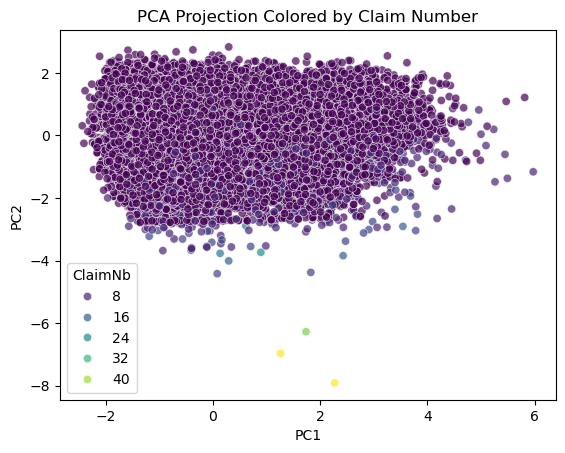

In [76]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('Project_description_and_data/claims_train.csv')     

def pca(df):
    df = df.copy()
    df = df[df['ClaimNb']>1]
    
    features = ['ClaimNb', 'DrivAge_log', 'VehPower', 'VehAge_log', 'Density_log', 'BonusMalus']

    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)   # for 2D visualization
    X_pca = pca.fit_transform(X_scaled)

    df["PC1"] = X_pca[:, 0]
    df["PC2"] = X_pca[:, 1]

    explained = pca.explained_variance_ratio_ 
    print(f"PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}, Total: {explained[:2].sum():.2%}")

    loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
    )
    print(loadings)
    return df

def visualisation(df):
    #df = pca(df)
    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="ClaimNb",
        data=df,
        palette="viridis",
        alpha=0.7
    )
    plt.title("PCA Projection Colored by Claim Number")
    plt.show()

tdf = transform(df)
pcaa = pca(tdf)
visualisation(pcaa)